In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("dataset/babies.csv")
df.head()

,case,bwt,gestation,parity,age,height,weight,smoke
0,1,120,284.0,0,27.0,62.0,100.0,0.0
1,2,113,282.0,0,33.0,64.0,135.0,0.0
2,3,128,279.0,0,28.0,64.0,115.0,1.0
3,4,123,NaN,0,36.0,69.0,190.0,0.0
4,5,108,282.0,0,23.0,67.0,125.0,1.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1236 entries, 0 to 1235
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   case       1236 non-null   int64  
 1   bwt        1236 non-null   int64  
 2   gestation  1223 non-null   float64
 3   parity     1236 non-null   int64  
 4   age        1234 non-null   float64
 5   height     1214 non-null   float64
 6   weight     1200 non-null   float64
 7   smoke      1226 non-null   float64
dtypes: float64(5), int64(3)
memory usage: 77.4 KB


In [5]:
df.describe()

,case,bwt,gestation,parity,age,height,weight,smoke
count,1236.000000,1236.000000,1223.000000,1236.000000,1234.000000,1214.000000,1200.000000,1226.000000
mean,618.500000,119.576861,279.338512,0.254854,27.255267,64.047776,128.625833,0.394780
std,356.946775,18.236452,16.027693,0.435956,5.781405,2.533409,20.971862,0.489003
min,1.000000,55.000000,148.000000,0.000000,15.000000,53.000000,87.000000,0.000000
25%,309.750000,108.750000,272.000000,0.000000,23.000000,62.000000,114.750000,0.000000
50%,618.500000,120.000000,280.000000,0.000000,26.000000,64.000000,125.000000,0.000000
75%,927.250000,131.000000,288.000000,1.000000,31.000000,66.000000,139.000000,1.000000
max,1236.000000,176.000000,353.000000,1.000000,45.000000,72.000000,250.000000,1.000000


In [6]:
#finding missing values
df.isnull().sum()

case          0
bwt           0
gestation    13
parity        0
age           2
height       22
weight       36
smoke        10
dtype: int64

In [7]:
#removing the missing values
df.dropna(inplace=True)

In [8]:
df.isnull().sum()

case         0
bwt          0
gestation    0
parity       0
age          0
height       0
weight       0
smoke        0
dtype: int64

In [9]:
#identifying duplicate values
df.duplicated().sum()

np.int64(0)

In [10]:
import matplotlib.pyplot as plt

In [11]:
df.columns

Index(['case', 'bwt', 'gestation', 'parity', 'age', 'height', 'weight',
       'smoke'],
      dtype='str')

In [12]:
df.drop(columns=['case'],inplace = True)

In [13]:
df.columns

Index(['bwt', 'gestation', 'parity', 'age', 'height', 'weight', 'smoke'], dtype='str')

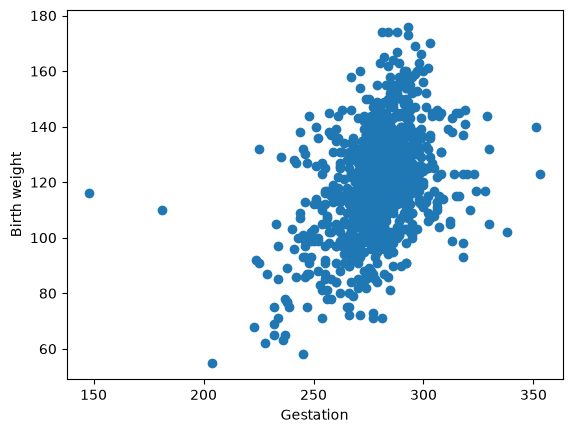

In [14]:
plt.scatter(df['gestation'], df['bwt'])
plt.xlabel("Gestation")
plt.ylabel("Birth weight")
plt.show()

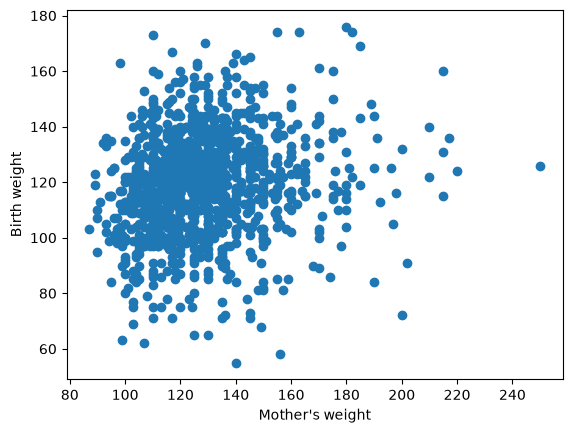

In [15]:
plt.scatter(df['weight'], df['bwt'])
plt.xlabel("Mother's weight")
plt.ylabel("Birth weight")
plt.show()

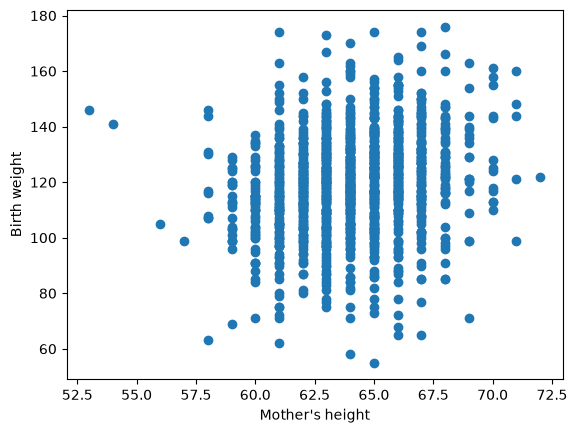

In [16]:
plt.scatter(df['height'], df['bwt'])
plt.xlabel("Mother's height")
plt.ylabel("Birth weight")
plt.show()

In [17]:
df.columns

Index(['bwt', 'gestation', 'parity', 'age', 'height', 'weight', 'smoke'], dtype='str')

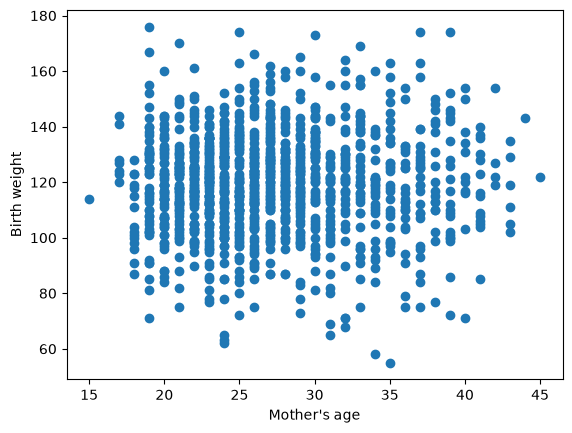

In [18]:
plt.scatter(df['age'], df['bwt'])
plt.xlabel("Mother's age")
plt.ylabel("Birth weight")
plt.show()

In [19]:
df['smoke'].unique()

array([0., 1.])

In [20]:
df['smoke'].value_counts()

smoke
0.0    715
1.0    459
Name: count, dtype: int64

In [21]:
df['smoke'].value_counts(normalize=True)*100

smoke
0.0    60.902896
1.0    39.097104
Name: proportion, dtype: float64

In [22]:
df['parity'].unique()

array([0, 1])

In [23]:
df['parity'].value_counts()

parity
0    866
1    308
Name: count, dtype: int64

In [24]:
#correlation matrix

df.corr()

,bwt,gestation,parity,age,height,weight,smoke
bwt,1.000000,0.407543,-0.043908,0.026983,0.203704,0.155923,-0.246800
gestation,0.407543,1.000000,0.080916,-0.053425,0.070470,0.023655,-0.060267
parity,-0.043908,0.080916,1.000000,-0.351041,0.043543,-0.096362,-0.009599
age,0.026983,-0.053425,-0.351041,1.000000,-0.006453,0.147322,-0.067772
height,0.203704,0.070470,0.043543,-0.006453,1.000000,0.435287,0.017507
weight,0.155923,0.023655,-0.096362,0.147322,0.435287,1.000000,-0.060281
smoke,-0.246800,-0.060267,-0.009599,-0.067772,0.017507,-0.060281,1.000000


In [25]:
#splitting dataset into x and y
y = df['bwt']
x = df.iloc[:,1:]
x.head()

,gestation,parity,age,height,weight,smoke
0,284.0,0,27.0,62.0,100.0,0.0
1,282.0,0,33.0,64.0,135.0,0.0
2,279.0,0,28.0,64.0,115.0,1.0
4,282.0,0,23.0,67.0,125.0,1.0
5,286.0,0,25.0,62.0,93.0,0.0


In [26]:
#train test split
##command : pip install scikit-learn

from sklearn.model_selection import train_test_split as tts

In [27]:
x_train, x_test, y_train, y_test = tts(x,y, test_size=0.20)

In [28]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge

In [29]:
lr = LinearRegression()
lasso = Lasso()
ridge = Ridge()

In [30]:
lr.fit(x_train, y_train) #takes the data and train
lasso.fit(x_train, y_train)
ridge.fit(x_train, y_train)


,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [31]:
lr_pred = lr.predict(x_test)
las_pred = lasso.predict(x_test)
rid_pred = ridge.predict(x_test)

In [32]:
#model evaluation
from sklearn.metrics import r2_score, mean_squared_error

In [33]:
lr_rscore = r2_score(y_test, lr_pred)
las_rsore = r2_score(y_test, las_pred)
rid_rsore = r2_score(y_test, rid_pred)

In [34]:
lr_mse = mean_squared_error(y_test, lr_pred)
las_mse = mean_squared_error(y_test, las_pred)
rid_mse = mean_squared_error(y_test, rid_pred)

In [35]:
print("\nPerformance of Linear Regression Model :")
print("R2score : ",lr_rscore)
print("MSE : ", lr_mse)


print("\nPerformance of Lasso Regression Model :")
print("R2score : ",las_rsore)
print("MSE : ", las_mse)


print("\nPerformance of Ridge Regression Model :")
print("R2score : ",rid_rsore)
print("MSE : ", rid_mse)





Performance of Linear Regression Model :
R2score :  0.20941647711506306
MSE :  272.73692813517647

Performance of Lasso Regression Model :
R2score :  0.21577902358355538
MSE :  270.54196539094727

Performance of Ridge Regression Model :
R2score :  0.20959679830739708
MSE :  272.67472060535675


In [ ]:
## selected model is linear regression 
#saving the model in pickle format
import pickle

In [37]:
with open("model/model.pkl", 'wb') as f :
    pickle.dump(lr, f) #f is file path